In [1]:
#Step 1: Data Importing & Cleaning
import pandas as pd

main_df = pd.read_csv("owid_climate_data.csv")
main_df.info 

<bound method DataFrame.info of       Country Name Country Code  Year  CO2 Emissions Per Capita  \
0      Afghanistan          AFG  1949                  0.001992   
1      Afghanistan          AFG  1950                  0.010837   
2      Afghanistan          AFG  1951                  0.011625   
3      Afghanistan          AFG  1952                  0.011468   
4      Afghanistan          AFG  1953                  0.013123   
...            ...          ...   ...                       ...   
26177     Zimbabwe          ZWE  2019                  0.672040   
26178     Zimbabwe          ZWE  2020                  0.547085   
26179     Zimbabwe          ZWE  2021                  0.645915   
26180     Zimbabwe          ZWE  2022                  0.648761   
26181     Zimbabwe          ZWE  2023                  0.683201   

       Annual Temperature Anomaly  
0                       -2.020418  
1                       -2.298886  
2                       -1.287201  
3                  

In [2]:
main_df['Country Name'].nunique() #Gathers all the country names and counts them

231

In [3]:
main_df['Year'].agg(['min', 'max'])
year_min = 1750
year_max = 2023
year_range = year_max - year_min
print(f"The year range is: {year_range}") #Calculating the Year Range

The year range is: 273


In [4]:
main_df.columns #Gathering columnn names of the dataset

Index(['Country Name', 'Country Code', 'Year', 'CO2 Emissions Per Capita',
       'Annual Temperature Anomaly'],
      dtype='str')

In [5]:
#Step 1.5 Cleaning the Dataset

# 1.5.1. Inspecting if there is any NaN or missing values in the DF before cleaning! I know in the Course Reader it gave us the hint to drop CO2 and Temperature, but this is to just check everything
print("\nMissing values per column:")
print(main_df.isnull().sum())



Missing values per column:
Country Name                      0
Country Code                   3287
Year                              0
CO2 Emissions Per Capita          0
Annual Temperature Anomaly    11863
dtype: int64


In [6]:
#1.5.2 Removing the NaN values from Country Code, CO2 Emissions Per Capita, and Temperature
cleaned_df = main_df.dropna(subset=["Country Code", "CO2 Emissions Per Capita", "Annual Temperature Anomaly"])
print("nOriginal dataframe info, for comparison on dataset size change:", main_df.info())
print("\n --------")
print("\nCleaned dataframe info:", cleaned_df.info())
print("\n From row range of 26182 to 14319.")

<class 'pandas.DataFrame'>
RangeIndex: 26182 entries, 0 to 26181
Data columns (total 5 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Country Name                26182 non-null  str    
 1   Country Code                22895 non-null  str    
 2   Year                        26182 non-null  int64  
 3   CO2 Emissions Per Capita    26182 non-null  float64
 4   Annual Temperature Anomaly  14319 non-null  float64
dtypes: float64(2), int64(1), str(2)
memory usage: 1022.9 KB
nOriginal dataframe info, for comparison on dataset size change: None

 --------
<class 'pandas.DataFrame'>
Index: 14319 entries, 0 to 26181
Data columns (total 5 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Country Name                14319 non-null  str    
 1   Country Code                14319 non-null  str    
 2   Year                        14319 non

In [7]:
#1.5.3 Resetting the index after dropping rows to make the DataFrame look cleaner
cleaned_df = cleaned_df.reset_index(drop=True)
#1.5.4 Displaying first 5 rows after cleaning
cleaned_df.head(5)

,Country Name,Country Code,Year,CO2 Emissions Per Capita,Annual Temperature Anomaly
0,Afghanistan,AFG,1949,0.001992,-2.020418
1,Afghanistan,AFG,1950,0.010837,-2.298886
2,Afghanistan,AFG,1951,0.011625,-1.287201
3,Afghanistan,AFG,1952,0.011468,-1.237078
4,Afghanistan,AFG,1953,0.013123,-1.084867


In [8]:
#Step 2: Sets & Functions
#2.1 Creating a set of all unique countries
country_set = set(cleaned_df["Country Name"]) #Set is used here instead of a list because it removes duplicates of the country names (SAE-AU, 2025, p. 10)
print(country_set)
print(f"Total unique countries/regions: {len(country_set)}")

{'Chile', 'Solomon Islands', 'Montenegro', 'Bhutan', 'Guyana', 'Norway', 'Congo', 'Japan', 'Croatia', 'Italy', 'New Zealand', 'Nicaragua', 'Eritrea', 'Qatar', 'Morocco', 'Belize', 'Luxembourg', 'Switzerland', 'Seychelles', 'South Sudan', 'Sao Tome and Principe', 'Equatorial Guinea', 'Trinidad and Tobago', 'Pakistan', 'Central African Republic', 'Iran', 'Oman', 'Zimbabwe', 'Gabon', 'Senegal', 'World', 'Ukraine', 'Uruguay', 'Kosovo', 'Afghanistan', 'Saudi Arabia', 'Denmark', 'Samoa', 'Spain', 'Bulgaria', 'Austria', 'Ecuador', 'Russia', 'Faroe Islands', 'Germany', 'Cameroon', 'Israel', 'Kuwait', 'Chad', 'Iraq', 'North Korea', 'Jamaica', 'Honduras', 'Mauritius', 'Slovenia', 'Armenia', 'Paraguay', 'Liberia', 'Greece', 'Albania', 'Uzbekistan', 'Kiribati', 'Australia', 'Bangladesh', 'Laos', 'French Polynesia', "Cote d'Ivoire", 'Fiji', 'Lebanon', 'Tunisia', 'Vanuatu', 'Belgium', 'Guinea-Bissau', 'South Korea', 'Rwanda', 'Finland', 'Kazakhstan', 'Czechia', 'Brazil', 'Georgia', 'Niger', 'Canada'

In [9]:
#2.2 Function to retrieve rows by country and year range
def get_country_data(df, country, start_year, end_year): 
    filtered_country_df = df[
        (df["Country Name"] == country) &
        (df['Year'] >= start_year) &
        (df['Year'] <= end_year)
        ]
    return filtered_country_df.reset_index(drop=True) 

In [10]:
#2.3 Testing the Function - North Korea, 1970-2023
north_korea_df = get_country_data(cleaned_df, country="North Korea", start_year=1970, end_year=2023)
print("\n Result of North Korea's CO2 Emissions and Annual temperatures throughout 1970-2034")
print(f"\n The number of rows returned: {len(north_korea_df)}")
print("\n", north_korea_df)


 Result of North Korea's CO2 Emissions and Annual temperatures throughout 1970-2034

 The number of rows returned: 54

    Country Name Country Code  Year  CO2 Emissions Per Capita  \
0   North Korea          PRK  1970                  4.842656   
1   North Korea          PRK  1971                  6.900217   
2   North Korea          PRK  1972                  5.602802   
3   North Korea          PRK  1973                  5.952504   
4   North Korea          PRK  1974                  6.094351   
5   North Korea          PRK  1975                  6.341626   
6   North Korea          PRK  1976                  6.381039   
7   North Korea          PRK  1977                  6.497850   
8   North Korea          PRK  1978                  6.101336   
9   North Korea          PRK  1979                  6.131366   
10  North Korea          PRK  1980                  6.255628   
11  North Korea          PRK  1981                  6.183090   
12  North Korea          PRK  1982             

In [11]:
#Step 3: Logical Filtering
"""Filtering all countries where CO2 emissions are above 10 metric tons in 2020"""

#Step 3.1 Filtering into a new dataframe that only contains the countries with the conditions of being in 2020 and co2 emissions greater than 10 metric tonnes
countries_in_2020_and_co2_df = cleaned_df[(cleaned_df["Year"] == 2020) & (cleaned_df["CO2 Emissions Per Capita"] > 10)]


In [12]:
#Step 3.2 Displaying only  country, co2, and temperature columns in the new DF created
print(countries_in_2020_and_co2_df[["Country Name", "CO2 Emissions Per Capita", "Annual Temperature Anomaly"]])

               Country Name  CO2 Emissions Per Capita  \
707               Australia                 15.506062   
1033                Bahrain                 25.215979   
1867                 Brunei                 24.939121   
2326                 Canada                 13.795024   
4502          Faroe Islands                 14.426020   
6985             Kazakhstan                 13.113933   
7230                 Kuwait                 21.739220   
7896             Luxembourg                 12.806264   
8578               Mongolia                 11.265909   
9177          New Caledonia                 17.981370   
9813                   Oman                 15.174401   
10575                 Qatar                 36.564110   
10743                Russia                 11.156080   
11166          Saudi Arabia                 19.879406   
11938           South Korea                 11.524341   
12967   Trinidad and Tobago                 23.677786   
13442  United Arab Emirates    

In [13]:
#Step 3.3 Sort countries from highest co2 emissions to lowest for better readability
sorted_co2_in_2020 = countries_in_2020_and_co2_df.sort_values("CO2 Emissions Per Capita", ascending=False)
sorted_co2_in_2020

,Country Name,Country Code,Year,CO2 Emissions Per Capita,Annual Temperature Anomaly
10575,Qatar,QAT,2020,36.564110,0.610190
1033,Bahrain,BHR,2020,25.215979,0.544875
1867,Brunei,BRN,2020,24.939121,0.488073
12967,Trinidad and Tobago,TTO,2020,23.677786,0.303785
13442,United Arab Emirates,ARE,2020,23.006842,0.546586
7230,Kuwait,KWT,2020,21.739220,0.725706
11166,Saudi Arabia,SAU,2020,19.879406,0.557455
9177,New Caledonia,NCL,2020,17.981370,0.353113
707,Australia,AUS,2020,15.506062,0.413426
9813,Oman,OMN,2020,15.174401,0.060757


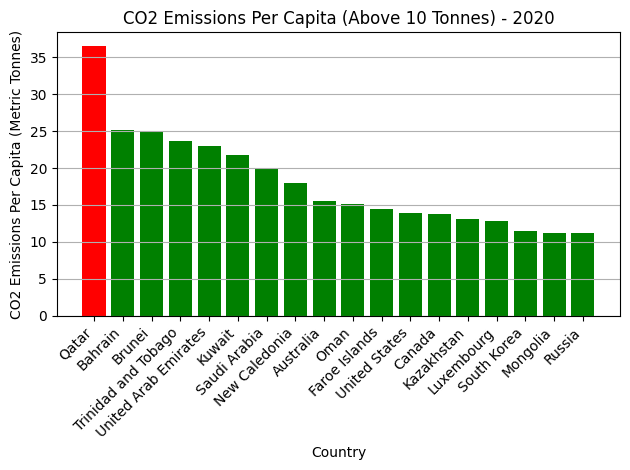

In [14]:
"""Here I plan to display the above as a bar chart to demonstrate which country had emitted most CO2 emissions in 2020"""
#Step 3.4 Importing matplotlib and creating a bar chart
import matplotlib.pyplot as plt

colours = ["red" if i == 0 else "green" for i in range(len(sorted_co2_in_2020))] #Added colour to differentiate the highest bar further. Also since I sorted the values earlier, the first bar is always red.
plt.bar(sorted_co2_in_2020["Country Name"], sorted_co2_in_2020["CO2 Emissions Per Capita"], color=colours)
plt.title("CO2 Emissions Per Capita (Above 10 Tonnes) - 2020")
plt.xlabel("Country")
plt.ylabel("CO2 Emissions Per Capita (Metric Tonnes)")
plt.xticks(rotation=45, ha="right") #Rotating country names so they stop overlapping
plt.grid(axis="y") #Adding gridlines only to the horizontal axis to make values easier to read
plt.tight_layout() # Adjust spacing so nothing gets cut off
plt.show()


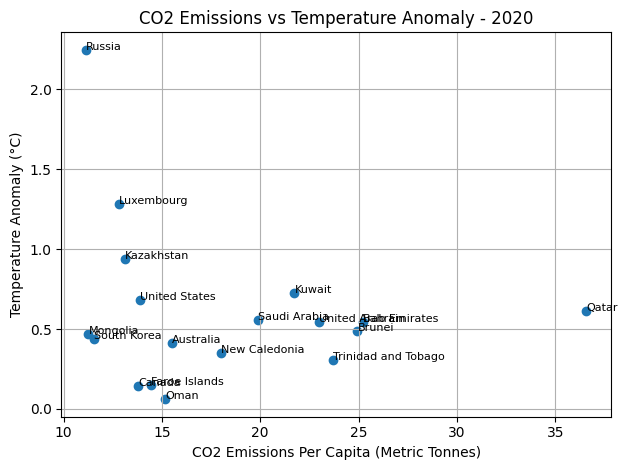

In [15]:
#Step 3.5 Creating a scatterplot
"""Decided to include a scatterplot to show the relationship of how CO2 emissions relate to higher temoperatures."""
plt.scatter(sorted_co2_in_2020["CO2 Emissions Per Capita"], sorted_co2_in_2020["Annual Temperature Anomaly"])
for i, country in enumerate(sorted_co2_in_2020["Country Name"]): #Adding label for each country that's represented by its own dot
    plt.text(sorted_co2_in_2020["CO2 Emissions Per Capita"].iloc[i], sorted_co2_in_2020["Annual Temperature Anomaly"].iloc[i], country, fontsize=8)

plt.title("CO2 Emissions vs Temperature Anomaly - 2020")
plt.xlabel("CO2 Emissions Per Capita (Metric Tonnes)")
plt.ylabel("Temperature Anomaly (°C)")
plt.grid(True) #Includes both axis to show gridlines
plt.tight_layout()
plt.show()

In [16]:
#Step 4: Probability & Summary Statistics
#Step 4.1 Calculate mean, max, min of temperature per year
temp_by_year = cleaned_df.groupby("Year")["Annual Temperature Anomaly"].agg(["mean", "min", "max"]) #Aggregate function lets me calculate multiple stats in one go
print("\n ---  Temperature Summary by Year ---") 
print(temp_by_year)


 ---  Temperature Summary by Year ---
          mean       min       max
Year                              
1940 -1.624415 -3.825056  0.423903
1941 -1.251653 -3.941369  1.779448
1942 -1.368997 -3.628582  0.683115
1943 -1.021218 -2.985201  1.080043
1944 -1.000902 -2.997106  0.915558
...        ...       ...       ...
2019  0.601391 -0.226331  1.697816
2020  0.580830 -0.231912  2.247584
2021  0.411804 -0.655329  1.511456
2022  0.444629 -0.582847  1.773571
2023  0.862665 -0.266950  1.894608

[84 rows x 3 columns]


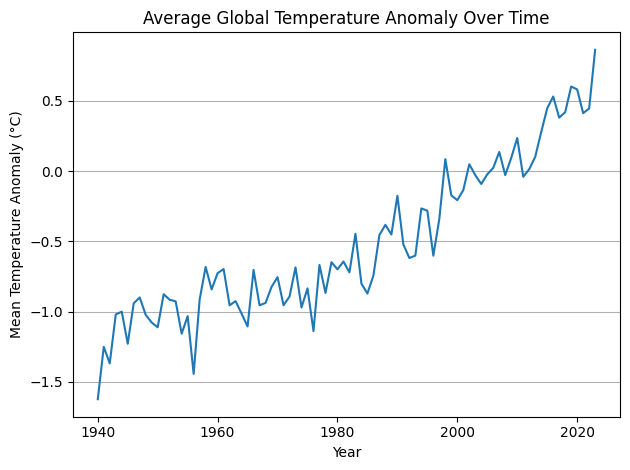

'"Uh oh, that\'s a consistent increase!'

In [17]:
#Step 4.2 Showing the progress of temperature from 1940-2023 by displaying it as a line chart
temp_by_year["mean"].plot(kind="line")
plt.title("Average Global Temperature Anomaly Over Time")
plt.xlabel("Year")
plt.ylabel("Mean Temperature Anomaly (°C)")
plt.grid(axis="y")
plt.tight_layout()
plt.show()
""""Uh oh, that's a consistent increase!"""

In [18]:
#Step 4.3 Probability Calculation
exceeding = cleaned_df[cleaned_df["Annual Temperature Anomaly"] > 1.5]
probability = round(len(exceeding) / len(cleaned_df) * 100, 2) #Possibilities that satisfy condition of > 1.5 divided by number of total possibilities
print("\n --- Probability that Temperature Exceeds 1.5 Degrees ---")
print(f"Rows exceeding 1.5 degrees: {len(exceeding)}")
print(f"Total rows in dataset: {len(cleaned_df)}")
print(f"Probability: {probability}%")
                


 --- Probability that Temperature Exceeds 1.5 Degrees ---
Rows exceeding 1.5 degrees: 49
Total rows in dataset: 14319
Probability: 0.34%


In [19]:
#Step 5: Counting Principles
combos = cleaned_df.groupby(["Country Name", "Year"]).size() #Grouping by both country and year to find unique combinations. .Size() counts how many rows exist for each combo.
print("\n --- Unique Year-Country Combinations ---")
print("Number of combinations of the cleaned DataFrame:", len(combos))


 --- Unique Year-Country Combinations ---
Number of combinations of the cleaned DataFrame: 14319


In [20]:
#Step 5.1 Printing how many unique countries and years exist individually only used the cleaned dataframe
print("Unique countries:", cleaned_df["Country Name"].nunique())
print("Unique years:", cleaned_df["Year"].nunique())

Unique countries: 187
Unique years: 84


In [21]:
#Step 6: Graph theory & networks
"""Build a simple country-emission similarity graph"""

import networkx as nx
G = nx.Graph()

#Step 6.1 Using the earlier DF containing countries in 2020, from step 3.3
for _, row in sorted_co2_in_2020.iterrows(): 
    country_name = row["Country Name"]
    country_co2 = row["CO2 Emissions Per Capita"]
    G.add_node(country_name, co2=country_co2) #CO2 value is stored as a node attribute to be ref'd later when sizing nodes

In [22]:
#Step 6.2 Adding the weight between countries with similar emissions (< 1.0)
threshold = 1.0

for country_a in sorted_co2_in_2020["Country Name"]:
    for country_b in sorted_co2_in_2020["Country Name"]:
        if country_a == country_b: #Skips if comparing a country to itself
            continue 
        co2_a = G.nodes[country_a]["co2"] #Get CO2 value for each country
        co2_b = G.nodes[country_b]["co2"]
        difference = abs(co2_a - co2_b)
        difference = round(difference, 2) #Calcuatling difference between two countries
        if difference <= threshold:
            G.add_edge(country_a, country_b, weight=difference)


In [23]:
#Step 6.3 Printing the properties of the graph
print("--- Graph Structure ---")
print(f"Number of nodes (countries): {G.number_of_nodes()}")
print(f"Number of edges (similar pairs): {G.number_of_edges()}")
print(f"Is the network fully connected? {nx.is_connected(G)}") #Indicates isolated countries exist

print("\n--- Degree (number of similar-emission neighbours) ---") #Similarity of emissions + less of an outlier
for node in G.nodes():
    print(f"  {node}: {G.degree(node)} connection(s)")

centrality = nx.betweenness_centrality(G)
print("\n--- Betweenness Centrality (higher = more of a bridge) ---")
for country, score in sorted(centrality.items(), key=lambda x: -x[1]):
    print(f"  {country}: {round(score, 3)}")

--- Graph Structure ---
Number of nodes (countries): 18
Number of edges (similar pairs): 14
Is the network fully connected? False

--- Degree (number of similar-emission neighbours) ---
  Qatar: 0 connection(s)
  Bahrain: 1 connection(s)
  Brunei: 1 connection(s)
  Trinidad and Tobago: 1 connection(s)
  United Arab Emirates: 1 connection(s)
  Kuwait: 0 connection(s)
  Saudi Arabia: 0 connection(s)
  New Caledonia: 0 connection(s)
  Australia: 1 connection(s)
  Oman: 2 connection(s)
  Faroe Islands: 3 connection(s)
  United States: 3 connection(s)
  Canada: 4 connection(s)
  Kazakhstan: 3 connection(s)
  Luxembourg: 2 connection(s)
  South Korea: 2 connection(s)
  Mongolia: 2 connection(s)
  Russia: 2 connection(s)

--- Betweenness Centrality (higher = more of a bridge) ---
  Faroe Islands: 0.059
  Oman: 0.037
  Canada: 0.037
  United States: 0.011
  Kazakhstan: 0.004
  Qatar: 0.0
  Bahrain: 0.0
  Brunei: 0.0
  Trinidad and Tobago: 0.0
  United Arab Emirates: 0.0
  Kuwait: 0.0
  Saudi A

In [24]:
#Step 6.4 Stating the country that acts as a bridge along shortest path between other countries
central_connector = nx.betweenness_centrality(G)
top_connector = max(central_connector, key=central_connector.get)
print(f"\nThe country that is the most connected is {top_connector}.")


The country that is the most connected is Faroe Islands.


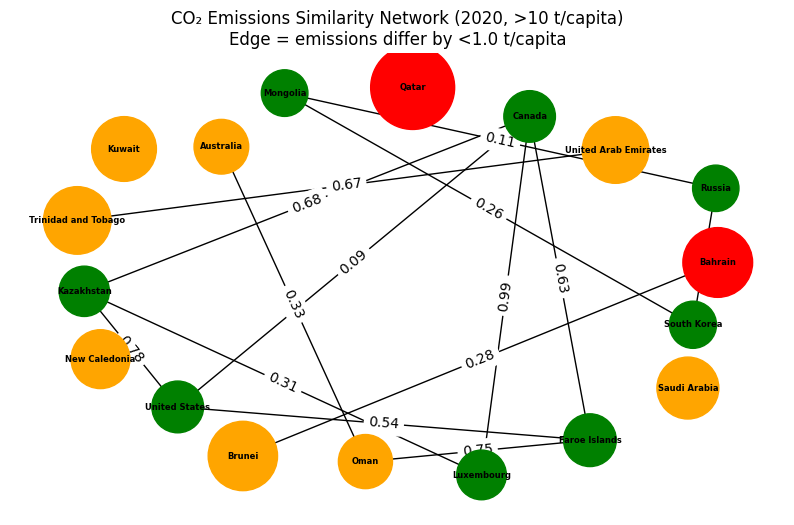

In [34]:
#Step 6.5 Visualising the network
pos = nx.spring_layout(G, seed=42, k=3)
node_colours = []
for node in G.nodes():
    co2_value = G.nodes[node]["co2"]
    if co2_value >= 25:
        node_colours.append("red")   # Highest emitter
    elif co2_value >= 15:
        node_colours.append("orange")       # Medium emitter
    else:
        node_colours.append("green")      # Okayish emitter

node_sizes = [] #Sizing each node by its CO2 value so higher emitters appear larger etc.
for node in G.nodes():
    co2_value = G.nodes[node]["co2"]
    size = max(co2_value * 100, 800)
    node_sizes.append(size)

plt.figure(figsize=(10, 6))
plt.title("CO₂ Emissions Similarity Network (2020, >10 t/capita)\nEdge = emissions differ by <1.0 t/capita")
nx.draw(G, pos,
        with_labels=True,
        node_color=node_colours,
        node_size=node_sizes,
        font_size=6,
        font_weight="bold")

edge_labels = nx.get_edge_attributes(G, "weight") #Drawing edge weight labels separately because nx.draw() doesn't support it.
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels) #Shows exact CO2 difference between each connected pair.

#Step 6.6 Saving and sharing
plt.savefig("step6_co2_network.png")
plt.show()